**Table of contents**<a id='toc0_'></a>    
- [Data & Setup](#toc1_)    
  - [Setup](#toc1_1_)    
  - [Downlowading data](#toc1_2_)    
  - [Datasets](#toc1_3_)    
- [Utils: plot loss and compare patterns (candles)](#toc2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

Are patterns in charts real? If so, could a model learn them, and represent them in a more suitable manner? For instance: pattern -> $[0,1]^{\text{latent\_dim}}$.

Since _chartists_ base their patterns on drawing lines, the activation functions will always be `ReLU`s.

As default sequence length (number of candles), the default sequence length is **24 daily** (`seq_len = 24`, `PERIOD="1d"`) candles, which roughly corresponds to one trading month in markets that are not open every day.

# <a id='toc1_'></a>[Data & Setup](#toc0_)

Important variables and data structures resultant from this section:

- `TICKERS` - Symbols of the prices. By default some ETF's symbols.
- `FEATURES` - Characteristics to use. By default Open, High, Low, Close (in that order).
- `DEVICE` - cpu or gpu
  
- `tickers_dfs: dict[str, pd.DataFrame]` - Dictionary mapping each 
    ticker symbol to its corresponding DataFrame.
- `train_dataset`
- `val_dataset`
- `test_dataset`

## <a id='toc1_1_'></a>[Setup](#toc0_)

In [ ]:
# GLOBAL PARAMETERS ALONG THE NOTEBOOK

import torch
import yfinance as yf
import pandas as pd
from pathlib import Path
from datetime import datetime

START_DATE = "2000-01-01"
END_DATE = datetime.now().date()

SEED = 1234 # seed for random generators

# ETF Tickers
TICKERS = ["SPY", "QQQ", "IWM", "DIA",
           "VTI", "VEA", "EEM", "GLD", "TLT", "XLF"]

PERIOD = "1d"

N_CANDLES = 24

FEATURES = ["Open", "High", "Low", "Close"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

## <a id='toc1_2_'></a>[Downlowading data](#toc0_)

In [2]:
from typing import cast

df_tickers = yf.download(
    TICKERS,
    start=START_DATE,
    auto_adjust=True,
    end=END_DATE
)

if df_tickers is None:
    raise RuntimeError("The dataframe was not properly downloaded")
else:
    df_tickers = cast(pd.DataFrame, df_tickers) # For type hints
    
df_tickers = df_tickers.dropna()

tickers_dfs:dict[str, pd.DataFrame] = {}
for t in TICKERS:
    if type(df_tickers.xs(t, level=1, axis=1)) == pd.DataFrame:
        tickers_dfs[t] = cast(pd.DataFrame, df_tickers.xs(t, level=1, axis=1))

[*********************100%***********************]  10 of 10 completed


## <a id='toc1_3_'></a>[Datasets](#toc0_)

DataLoaders to be created before training loop with the proper **batch_size**.

In [3]:
from TickerDataset import TickerDataset
from torch.utils.data import ConcatDataset
from torch.utils.data import random_split

tickers_datasets = {}
for t in TICKERS:
  tickers_datasets[t] = TickerDataset(
    df_ticker=tickers_dfs[t],
    n_candles=N_CANDLES,
    features=FEATURES,
    device=DEVICE
  )

all_tickers_dataset = ConcatDataset(
    list(tickers_datasets.values())
)

N = len(all_tickers_dataset)

train_size = int(0.70 * N)
val_size = int(0.15 * N)
test_size = N - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    all_tickers_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# <a id='toc2_'></a>[Utils: plot loss and compare patterns (candles) functions](#toc0_)

In [4]:
import matplotlib.pyplot as plt

def plot_loss(loss_training, loss_val=None):
    """ Plots the training loss and, optionally, the validation loss. 
    
    Parameters
    ---------- 
    loss_training : sequence 
        Training loss for each epoch. 
    loss_val : sequence, optional 
        Validation loss for each epoch. 
        Must have the same length as loss_training.
    """

    if loss_val is not None and len(loss_val) != len(loss_training):
        raise ValueError(
            "loss_val must have same length as loss_training. "
            f"len(loss_training)={len(loss_training)}, "
            f"len(loss_val)={len(loss_val)}."
        )

    epochs = range(1, len(loss_training) + 1)

    plt.figure(figsize=(8, 4))

    plt.plot(
        epochs,
        loss_training,
        label="training loss"
    )

    if loss_val is not None:
        plt.plot(
            epochs,
            loss_val,
            label="validation loss"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Autoencoder training")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import pandas as pd
import mplfinance as mpf
import random


def plot_candles(ohlc: list[list[float]],
                 dates: pd.DatetimeIndex):
    """Plot OHLC candlesticks using the provided date index.

    Parameters
    ----------
    ohlc : list[list[float]] 
        List of candles, where each candle contains four values: Open, High, Low, and Close. 
    dates : pd.DatetimeIndex 
        Date index corresponding to the OHLC data. Must have the same length as ohlc. 
    """

    if len(dates) != len(ohlc):
        raise ValueError(
            "The date index must have the same length as ohlc. "
            f"len(dates)={len(dates)}, len(ohlc)={len(ohlc)}."
        )

    df = pd.DataFrame(
        ohlc,
        columns=["Open", "High", "Low", "Close"],
        index=dates
    )

    mpf.plot(
        df,
        type="candle"
    )


def random_compare(tickers_dfs,
                   tickers, 
                   model,
                   n_candles=24, 
                   device=None):
    ticker = random.choice(tickers)
    df = tickers_dfs[ticker]
    start = random.randint(0, len(df) - n_candles)
    end = start + n_candles
    window = df[["Open", "High", "Low", "Close"]].iloc[start:end]

    dates = window.index

    x = torch.tensor(
        window.to_numpy(),
        dtype=torch.float64
    ).unsqueeze(0)

    if device is not None:
        x = x.to(device)

    model.eval()

    with torch.no_grad():
        prediction = model(x)

    prediction = prediction.squeeze(0).cpu().numpy()

    print(f"Ticker: {ticker}")
    print(f"Window: {start}:{end}")

    print("Real:")
    plot_candles(
        window.to_numpy(),
        dates
    )

    print("Reconstruction:")
    plot_candles(
        prediction,
        dates
    )

    return ticker, start, window, prediction

# Model, training and testing 1

In [6]:
from ChartistAutoencoder import ChartistAutoencoder
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # Previously used already... hmm...

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# model_1: a basic model with everything as default
model_1 = ChartistAutoencoder(
    device=DEVICE,
    seq_len=N_CANDLES,
    n_features=len(FEATURES)
)

In [7]:
from TrainingLoop import train_autoencoder
from torch.utils.data import DataLoader

# Train
train_params_1 = {
    "learning_rate": 1e-4,
    "batch_size": 128,
    "epochs": 100,
    "loss_fn": torch.nn.MSELoss(),
    "optimizer": torch.optim.Adam
}

model_1, train_loss_1, val_loss_1 = train_autoencoder(
    model=model_1,
    train_dataloader=DataLoader(train_dataset,
                                batch_size=train_params_1["batch_size"]),
    epochs=train_params_1["epochs"],
    loss_fn=train_params_1["loss_fn"],
    optimizer=train_params_1["optimizer"](params=model_1.parameters(),
                                          lr=train_params_1["learning_rate"]),
    device=DEVICE,
    val_dataloader=DataLoader(
        val_dataset, batch_size=train_params_1["batch_size"])
)

/home/javier/.venvs/ProgIntArt/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
epoch: 100%|██████████| 100/100 [03:05<00:00,  1.85s/it, loss=2.3699e+00, lr=1.00e-04, val_loss=2.5128e+00]


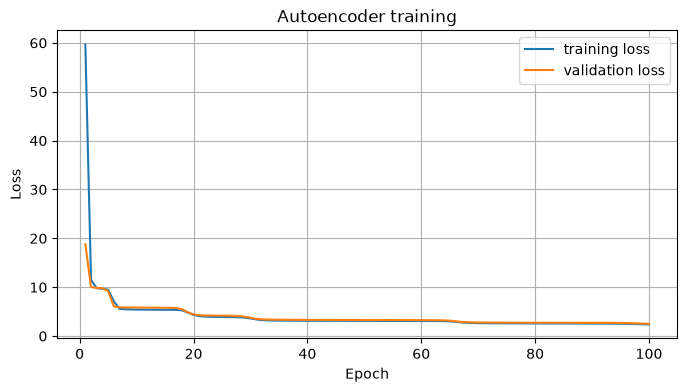

In [8]:
plot_loss(train_loss_1, val_loss_1)

Ticker: IWM
Ventana: 937:965
Real:


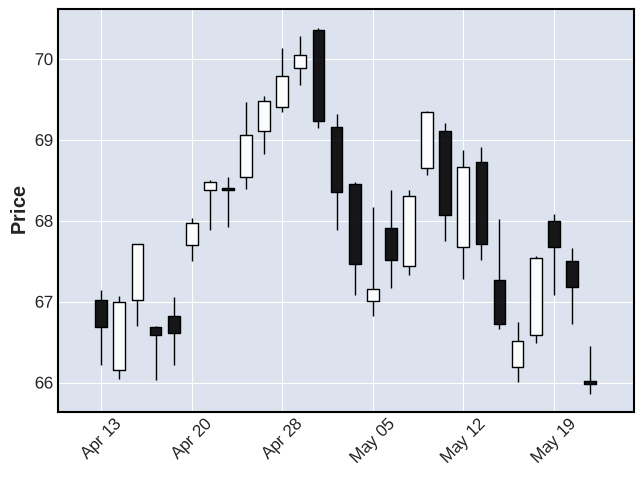

Reconstruction:


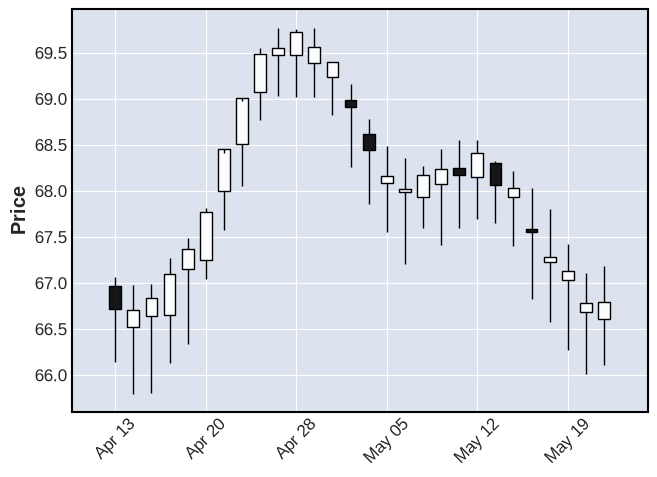

('IWM',
 937,
 Price            Open       High        Low      Close
 Date                                                  
 2011-04-13  67.016126  67.145857  66.221498  66.691788
 2011-04-14  66.156601  67.064747  66.043084  66.999878
 2011-04-15  67.024210  67.713425  66.699872  67.713425
 2011-04-18  66.691770  66.699881  66.026880  66.594467
 2011-04-19  66.821500  67.056639  66.221473  66.610680
 2011-04-20  67.705351  68.029690  67.502641  67.972931
 2011-04-21  68.386423  68.499947  67.891815  68.475616
 2011-04-25  68.410736  68.540468  67.924226  68.386406
 2011-04-26  68.540517  69.464877  68.394565  69.067566
 2011-04-27  69.108108  69.545957  68.832418  69.481094
 2011-04-28  69.408065  70.137824  69.343196  69.797272
 2011-04-29  69.886494  70.283805  69.675674  70.048660
 2011-05-02  70.364871  70.389195  69.148608  69.229691
 2011-05-03  69.156705  69.318871  67.883684  68.353973
 2011-05-04  68.451303  68.483737  67.080984  67.470184
 2011-05-05  67.008009  68.175624 

In [19]:
# This cell is meant to be run several times for checking eyeballing
# RUN THIS CELL SEVERAL TIMES!
random_compare(tickers_dfs, TICKERS, model_1, n_candles=N_CANDLES)